# Readout noise of sCMOS (Sony IMX174)

The goal is to provide a count/frequency per readout noise graph AND a similar one to the one on the poster

## Specification of setup and detector

|Parameter or Component | Value or Details  |
|:---|---:|
|Spectral Range |400 nm to 900 nm |
|Spectral Resolution| ∼1000 at 550 nm |
|Slit Width| 15 μm |
|Imaging Detector| Sony IMX174 (CMOS), 1936 × 1216, 5.86 μm pixel pitch |
|Imaging Performance |FWHM is within 3 pixels|


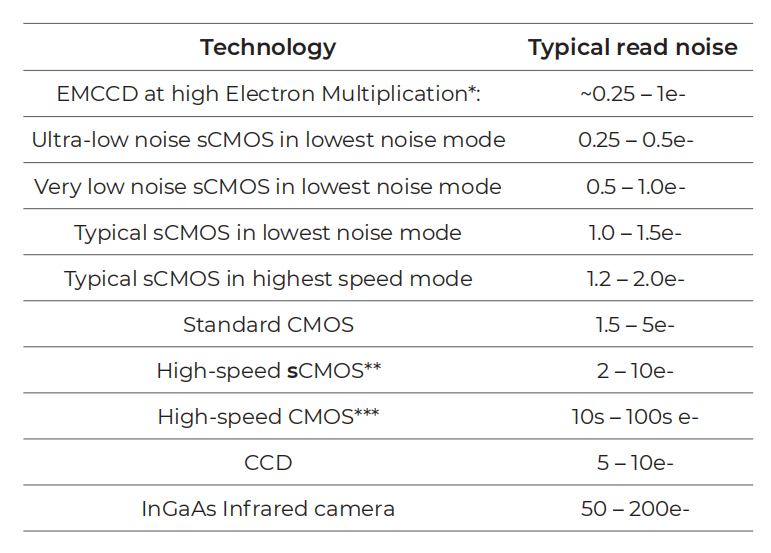

Table 1: Typical RMS read noise values for different scientific camera technologies

### Importation des libraries nécessaires

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from astropy.io import fits
from pathlib import Path

In [ ]:
%cd /Users/lalyboyer/Desktop/software/captures/BIAS

FOLDER = Path('TEST_BIAS_ALL')

FILES = os.listdir(f'{FOLDER}')
# FILES = [f for f in FOLDER.iterdir() if f.is_file() and f.suffix.lower() == '.fits']

WIDTH, HEIGHT = 1936, 1216 # detector pixels

# BIAS_ARRAY = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
STD_ARRAY = np.zeros(len(FILES)//2)

NUM = (len(FILES)-1) // 2
# for i, file in (enumerate(tqdm(FILES))):
for i in tqdm(range(NUM)):
    filepath_1 = FILES[2*i]# f'{FOLDER}/{file}'
    filepath_2 = FILES[2*i+1]

    # print(file)
    with fits.open(f'{FOLDER}/{filepath_1}') as hdul_1:
        data_1 = hdul_1[0].data.astype(np.float32)
    with fits.open(f'{FOLDER}/{filepath_2}') as hdul_2:
        data_2 = hdul_2[0].data.astype(np.float32)

    STD_ARRAY[i] = np.std(data_2 - data_1, ddof=1)

In [ ]:
STD_ARRAY = STD_ARRAY[:-1]/np.sqrt(2)*30500/4095

In [ ]:
def gaussian(x,var,mean):
    return 1/np.sqrt(2*np.pi*var)*np.exp(-1/2*(x-mean)**2/var)

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ax.grid(ls='--', c='lightgrey')
ax.set_xlabel('standard deviation')
ax.set_ylabel('Count')
ax.set_title("Représentation de la distribution de l'écart type du bruit électronique [e-]\n2 a 2 de 800 BIAS\n")
ax.set_axisbelow(True)

x_gauss = np.linspace(np.min(STD_ARRAY),np.max(STD_ARRAY),100)
y_gauss = gaussian(x_gauss,np.var(STD_ARRAY),np.mean(STD_ARRAY))

mean_STD = np.mean(STD_ARRAY)
var_STD = np.var(STD_ARRAY)

ax.hist(STD_ARRAY, bins=20, edgecolor='white', color='lightblue', alpha=0.8,density=True)
ax.plot(x_gauss,y_gauss, ls='--',color='steelblue',label=f'MEAN : {mean_STD:.2E}\nSTD    : {np.sqrt(var_STD):.2E}')
ax.legend()
plt.show()

This plot shows the pixel-wise read noise and bias signal distribution

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

a = 800 # nombre de bias
BIAS_ARRAY = np.zeros((HEIGHT, WIDTH,a), dtype=np.float32) # initialisation pour tous les stocker

for i in tqdm(range(a)):
    with fits.open(f'{FOLDER}/{FILES[i]}') as hdul:
        data = hdul[0].data.astype(np.float32)

        BIAS_ARRAY[:,:,i] = data

bias_map = np.mean(BIAS_ARRAY, axis=2)
noise_map = np.std(BIAS_ARRAY, axis=2)

gain = 30500 / 4095
bias_electrons = bias_map * gain
noise_electrons = noise_map * gain

bias_flat = bias_electrons.flatten()
noise_flat = noise_electrons.flatten()

In [ ]:
g = sns.jointplot(x=bias_flat, y=noise_flat, kind="hex", cmap="Blues")

# Optionnel : Mettre l'axe Y des histogrammes marginaux en log comme sur ton image
g.ax_marg_y.set_xscale('log') 
g.ax_marg_x.set_yscale('log')

g.set_axis_labels("Bias [e-]", "Read Noise [e-]")
plt.show()

In [ ]:
g = sns.jointplot(x=bias_flat, y=noise_flat, kind="scatter", cmap="Blues")

# Optionnel : Mettre l'axe Y des histogrammes marginaux en log comme sur ton image
g.ax_marg_y.set_xscale('log') 
g.ax_marg_x.set_yscale('log')

g.set_axis_labels("Bias [e-]", "Read Noise [e-]")
plt.show()

-----

In [ ]:
# Stack des différences
diff_stack = np.zeros((NUM, HEIGHT, WIDTH), dtype=np.float32)
for i in tqdm(range(NUM)):
    with fits.open(FOLDER/FILES[2*i]) as h1, fits.open(FOLDER/FILES[2*i+1]) as h2:
        diff_stack[i] = h1[0].data - h2[0].data

noise_map = np.std(diff_stack, axis=0) / np.sqrt(2) * 30500/4095

In [ ]:
plt.imshow(noise_map)
plt.colorbar()

In [ ]:
plt.hist(noise_map.flatten(), bins=50, edgecolor='white',color='lightblue')
plt.grid(ls='--', c='lightgrey')
plt.xlabel('σ local [e⁻]')
plt.title('Distribution du bruit pixel à pixel')
plt.gca().set_axisbelow(True)

---
## Flats

In [2]:
FLAT_EXP = 5000000 #µs
FLAT_EXPS = ['200','300','400','500','1000','2000','3000','4000','5000','10000','20000','30000','40000','50000','100000','200000','300000','400000','500000','600000','700000','800000','900000','1000000']#,'2000000']#,'3000000','5000000']

%cd /Users/lalyboyer/Desktop/software/captures/TRUE_FLAT

FOLDER = Path(f'FLAT_{FLAT_EXP}')

MASTER_FOLDER = Path(f'/Users/lalyboyer/Desktop/software/captures/TRUE_FLAT')

FILES = os.listdir(f'{FOLDER}')
# FILES = [f for f in FOLDER.iterdir() if f.is_file() and f.suffix.lower() == '.fits']

WIDTH, HEIGHT = 1936, 1216 # detector pixels
NUM_FILES = len(os.listdir(MASTER_FOLDER))*len(FILES)

FLAT_ARRAY = np.zeros((HEIGHT, WIDTH, NUM_FILES), dtype=np.float32)

# STD_ARRAY = np.zeros(len(FILES)//2)

/Users/lalyboyer/Desktop/software/captures/TRUE_FLAT


In [ ]:
# for j in range(len(os.listdir(MASTER_FOLDER))):
#     # print(FLAT_EXPS[j])
#     FOLDER = Path(f'FLAT_{FLAT_EXPS[j]}')
#     FILES = os.listdir(f'{FOLDER}')
#     for i, file in (enumerate(tqdm(FILES))):
#         with fits.open(f'{FOLDER}/{file}') as hdul :
#             FLAT_ARRAY[:,:,i] = hdul[0].data.astype(np.float32)


In [ ]:
# FLAT_PLOT = FLAT_ARRAY[:,:,0]

# fig, ax = plt.subplots(figsize=(8,5))

# ax.set_xlabel('Pixel x')
# ax.set_ylabel('Pixel y')
# ax.set_title(f'EXAMPLE OF ONE FLAT AT {FLAT_EXP} (MAX : {np.max(FLAT_PLOT)})')
# plt.imshow(FLAT_PLOT)
# plt.colorbar()

100%|██████████| 24/24 [00:15<00:00,  1.59it/s]


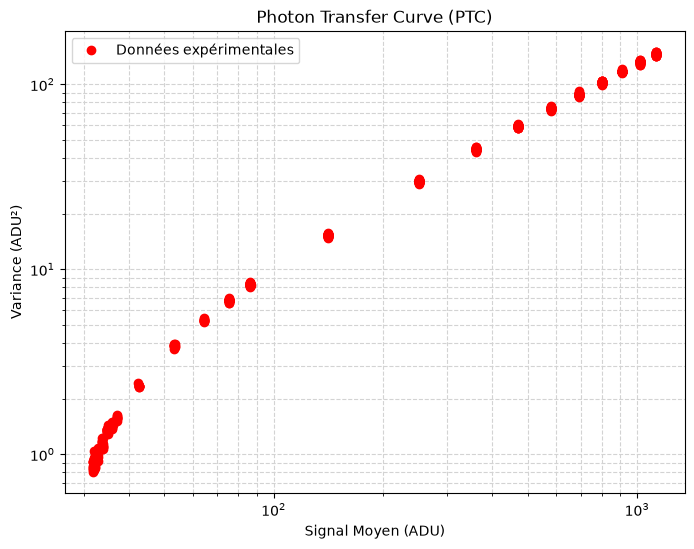

In [3]:
X_MIN, X_MAX = 450, 550
Y_MIN, Y_MAX = 550, 650

# Compter le nombre total de paires sur tous les dossiers
total_pairs = 0
for exp in FLAT_EXPS:
    n_files = len(os.listdir(Path(f'FLAT_{exp}')))
    total_pairs += n_files // 2

ROI_MEAN = np.zeros(total_pairs)
FLAT_VAR = np.zeros(total_pairs)
EXP_OF_POINT = np.zeros(total_pairs)  # utile pour colorer / debug par temps de pose

idx = 0  # <-- compteur global, incrémenté à chaque paire traitée
for j in tqdm(range(len(FLAT_EXPS))):
    FOLDER = Path(f'FLAT_{FLAT_EXPS[j]}')
    FILES = sorted(os.listdir(FOLDER))  # sorted() important pour l'ordre des paires
    n_pairs = len(FILES) // 2

    for i in range(n_pairs):
        filepath_1 = FILES[2*i]
        filepath_2 = FILES[2*i + 1]

        with fits.open(FOLDER / filepath_1) as hdul_1:
            ROI_1 = hdul_1[0].data[Y_MIN:Y_MAX, X_MIN:X_MAX].astype(np.float32)
        with fits.open(FOLDER / filepath_2) as hdul_2:
            ROI_2 = hdul_2[0].data[Y_MIN:Y_MAX, X_MIN:X_MAX].astype(np.float32)

        ROI_MEAN[idx] = np.mean((ROI_1 + ROI_2) / 2)
        FLAT_VAR[idx] = np.var(ROI_2 - ROI_1) / 2
        EXP_OF_POINT[idx] = FLAT_EXPS[j]

        idx += 1  # <-- on avance d'une case, jamais de collision ni de trou

signaux = ROI_MEAN
variances = FLAT_VAR

plt.figure(figsize=(8, 6))
plt.loglog(signaux, variances, 'ro', label='Données expérimentales')
plt.xlabel('Signal Moyen (ADU)')
plt.ylabel('Variance (ADU²)')
plt.title('Photon Transfer Curve (PTC)')
plt.grid(ls='--', c='lightgrey', which='both')
plt.legend()
plt.show()

In [ ]:


FLAT_VAR = np.zeros((NUM_FILES))
ROI_MEAN = np.zeros((NUM_FILES))

# ROI_FLAT = 

# for j in range(len(os.listdir(MASTER_FOLDER))):
#     # print(FLAT_EXPS[j])
#     FOLDER = Path(f'FLAT_{FLAT_EXPS[j]}')
#     FILES = os.listdir(f'{FOLDER}')
#     for i, file in (enumerate(tqdm(FILES))):
#         with fits.open(f'{FOLDER}/{file}') as hdul :
#             FLAT_ARRAY[:,:,i] = hdul[0].data.astype(np.float32)
idx = 0

for j in tqdm(range(len(FLAT_EXPS))):
    FOLDER = Path(f'FLAT_{FLAT_EXPS[j]}')
    FILES = os.listdir(f'{FOLDER}')
    for i in (range((len(FILES)//2))):
        filepath_1 = FILES[2*i]# f'{FOLDER}/{file}'
        filepath_2 = FILES[2*i+1]
        with fits.open(f'{FOLDER}/{filepath_1}') as hdul_1 :
            FLAT_1 = hdul_1[0].data.astype(np.float32) #FLAT_ARRAY[Y_MIN:Y_MAX, X_MIN:X_MAX, 2*i]
            ROI_1 = FLAT_1[Y_MIN:Y_MAX, X_MIN:X_MAX]
        with fits.open(f'{FOLDER}/{filepath_2}') as hdul_2 :
            FLAT_2 = hdul_2[0].data.astype(np.float32) #FLAT_ARRAY[Y_MIN:Y_MAX, X_MIN:X_MAX, 2*i]
            ROI_2 = FLAT_2[Y_MIN:Y_MAX, X_MIN:X_MAX]

        ROI_MEAN[idx] = np.mean((ROI_2 + ROI_1)/2)
        FLAT_VAR[idx] = np.var(ROI_2-ROI_1) / 2
        idx += 1

In [4]:
import matplotlib.pyplot as plt

signaux = np.array(ROI_MEAN)
variances = np.array(FLAT_VAR)
# std = np.sqrt(variances)

FLAT_VAR_AVG = np.zeros_like(FLAT_EXPS)
FLAT_MEAN_AVG = np.zeros_like(FLAT_EXPS)

for i in range(len(FLAT_VAR_AVG)):
    FLAT_VAR_AVG[i] = np.mean(variances[i*25:(i+1)*25])
    FLAT_MEAN_AVG[i] = np.mean(signaux[i*25:(i+1)*25])
    FLAT_VAR_AVG_ERR = np.std(variances[i*25:(i+1)*25])


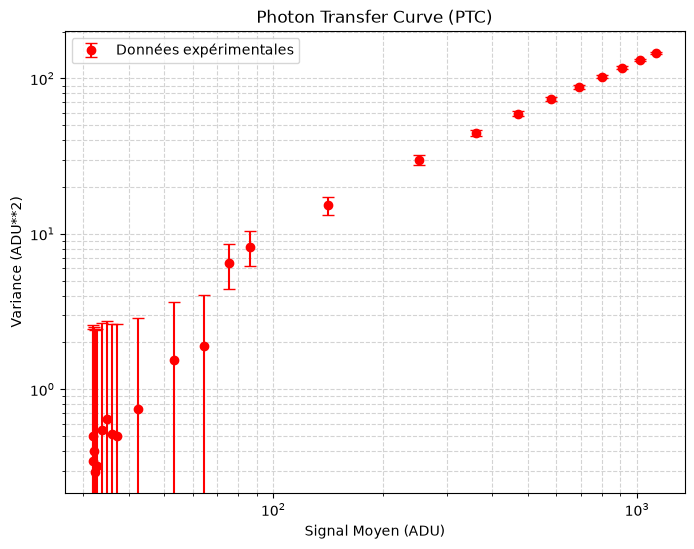

In [5]:
import matplotlib.pyplot as plt

signaux = np.array(ROI_MEAN)
variances = np.array(FLAT_VAR)
# std = np.sqrt(variances)

# FLAT_VAR_AVG = np.zeros_like(FLAT_EXPS)
# for i in range(len(FLAT_VAR_AVG)):
#     FLAT_VAR_AVG[i] = np.mean(variances[i*50:(i+1)*50])

plt.figure(figsize=(8, 6))
plt.errorbar(
    FLAT_MEAN_AVG.astype(float),
    FLAT_VAR_AVG.astype(float),
    yerr=FLAT_VAR_AVG_ERR.astype(float),
    fmt='ro',
    label='Données expérimentales',
    capsize=4,
)
plt.xscale('log'),
plt.yscale('log'),
plt.xlabel('Signal Moyen (ADU)')
plt.ylabel('Variance (ADU**2)')
plt.title('Photon Transfer Curve (PTC)')
plt.grid(ls='--',c='lightgrey',which='both')
# plt.xticks(np.arange(0, 251, 250))

# # Axe Y : de 0 à 300 avec un pas de 50
# plt.yticks(np.arange(0, 2201, 2200))
plt.legend()
plt.grid(True)

/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_81798/3125821233.py:2: RuntimeWarning: divide by zero encountered in log10
  log_v = np.log10(variances)
/Users/lalyboyer/Desktop/software/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1540: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_81798/3125821233.py:9: RuntimeWarning: divide by zero encountered in divide
  local_slope = np.diff(log_v_sorted) / np.diff(log_s_sorted)


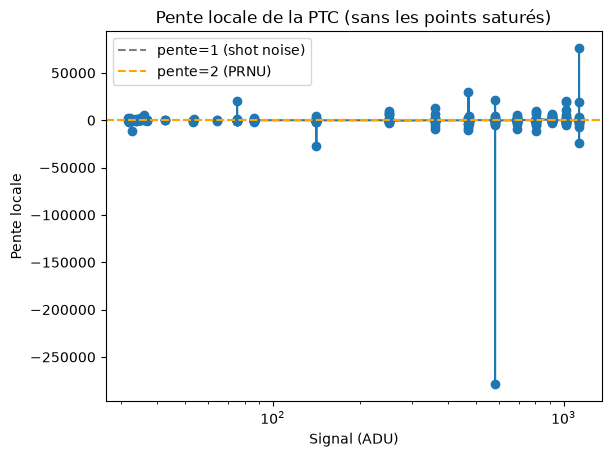

In [6]:
log_s = np.log10(signaux)
log_v = np.log10(variances)

# tri par signal croissant
order = np.argsort(log_s)
log_s_sorted = log_s[order]
log_v_sorted = log_v[order]

local_slope = np.diff(log_v_sorted) / np.diff(log_s_sorted)

plt.figure()
plt.plot(signaux[order][1:], local_slope, 'o-')
plt.xscale('log')
plt.axhline(1, ls='--', c='gray', label='pente=1 (shot noise)')
plt.axhline(2, ls='--', c='orange', label='pente=2 (PRNU)')
plt.xlabel('Signal (ADU)')
plt.ylabel('Pente locale')
plt.legend()
plt.title('Pente locale de la PTC (sans les points saturés)')
plt.show()

In [7]:
# Fit du gain, en excluant explicitement le coude ET la saturation
mask_fit = (signaux > 50) & (signaux < 1200)  # ajuste la borne haute selon où la pente commence à chuter
coeffs = np.polyfit(signaux[mask_fit], variances[mask_fit], 1)
gain = 1 / coeffs[0]
print(f'Gain estimé : {gain:.3f} e-/ADU')

Gain estimé : 7.495 e-/ADU


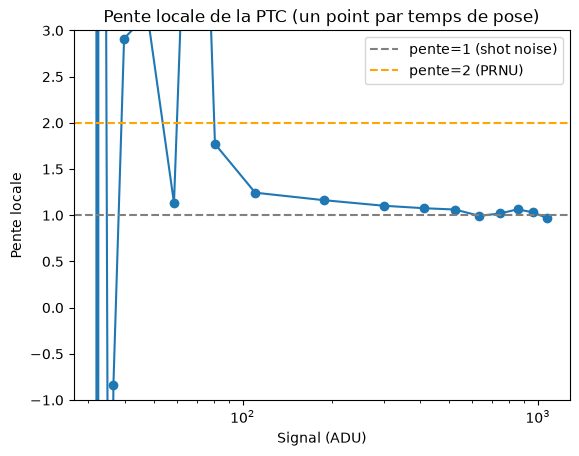

In [8]:
# 1. Regrouper par temps de pose (moyenne des paires ayant le même EXP_OF_POINT)
unique_exps = np.unique(EXP_OF_POINT)
mean_sig_per_exp = np.array([np.mean(signaux[EXP_OF_POINT == e]) for e in unique_exps])
mean_var_per_exp = np.array([np.mean(variances[EXP_OF_POINT == e]) for e in unique_exps])

# 2. Trier par signal croissant
order = np.argsort(mean_sig_per_exp)
sig_sorted = mean_sig_per_exp[order]
var_sorted = mean_var_per_exp[order]

# 3. Pente locale, maintenant sur des points bien espacés
log_s = np.log10(sig_sorted)
log_v = np.log10(var_sorted)
local_slope = np.diff(log_v) / np.diff(log_s)
sig_mid = np.sqrt(sig_sorted[1:] * sig_sorted[:-1])  # point milieu géométrique

plt.figure()
plt.plot(sig_mid, local_slope, 'o-')
plt.xscale('log')
plt.axhline(1, ls='--', c='gray', label='pente=1 (shot noise)')
plt.axhline(2, ls='--', c='orange', label='pente=2 (PRNU)')
plt.xlabel('Signal (ADU)')
plt.ylabel('Pente locale')
plt.ylim(-1, 3)  # zoom raisonnable
plt.legend()
plt.title('Pente locale de la PTC (un point par temps de pose)')
plt.show()

In [9]:
full_well_e = 30500
gain = 7.554  # e-/ADU

full_well_adu = full_well_e / gain
print(f'Full well attendu en ADU : {full_well_adu:.0f} ADU')

Full well attendu en ADU : 4038 ADU


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Résultats mesurés ---
gain = 7.554                  # e-/ADU, extrait du fit PTC (pente 1)
full_well_e = 30500           # e-, donné par le fabricant
bit_depth = 12
adc_max = 2**bit_depth - 1    # 4095 ADU

full_well_adu = full_well_e / gain

# --- Read noise (à partir de l'intercept du fit, en ADU) ---
# reprendre ton fit linéaire variance vs signal sur la zone linéaire :
mask_fit = (signaux > 50) & (signaux < 1200)
coeffs = np.polyfit(signaux[mask_fit], variances[mask_fit], 1)
slope, intercept = coeffs
gain_fit = 1 / slope
read_noise_adu = np.sqrt(max(intercept, 0))
read_noise_e = read_noise_adu * gain_fit

# --- Dynamic range ---
dynamic_range_db = 20 * np.log10(full_well_e / read_noise_e)
dynamic_range_bits = np.log2(full_well_e / read_noise_e)

print('===== Résumé caractérisation capteur =====')
print(f'Gain                  : {gain_fit:.3f} e-/ADU')
print(f'Read noise            : {read_noise_adu:.2f} ADU ({read_noise_e:.2f} e-)')
print(f'Full well (fabricant) : {full_well_e:.0f} e-')
print(f'Full well en ADU      : {full_well_adu:.0f} ADU')
print(f'ADC max (12-bit)      : {adc_max} ADU')
print(f'Marge full well/ADC   : {100*(1 - full_well_adu/adc_max):.1f} %')
print(f'Dynamic range         : {dynamic_range_db:.1f} dB ({dynamic_range_bits:.1f} bits)')

===== Résumé caractérisation capteur =====
Gain                  : 7.495 e-/ADU
Read noise            : 0.00 ADU (0.00 e-)
Full well (fabricant) : 30500 e-
Full well en ADU      : 4038 ADU
ADC max (12-bit)      : 4095 ADU
Marge full well/ADC   : 1.4 %
Dynamic range         : inf dB (inf bits)


/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_81798/2251168156.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  dynamic_range_db = 20 * np.log10(full_well_e / read_noise_e)
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_81798/2251168156.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  dynamic_range_bits = np.log2(full_well_e / read_noise_e)


In [11]:
# NUM = (len(FILES)-1) // 2
# # for i, file in (enumerate(tqdm(FILES))):
# for i in tqdm(range(NUM)):
#     filepath_1 = FILES[2*i]# f'{FOLDER}/{file}'
#     filepath_2 = FILES[2*i+1]

#     # print(file)
#     with fits.open(f'{FOLDER}/{filepath_1}') as hdul_1:
#         data_1 = hdul_1[0].data.astype(np.float32)
#     with fits.open(f'{FOLDER}/{filepath_2}') as hdul_2:
#         data_2 = hdul_2[0].data.astype(np.float32)

#     STD_ARRAY[i] = np.std(data_2 - data_1, ddof=1)